In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "sst2"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence', 'label', 'idx'],
    num_rows: 67349
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence': 'hide new secretions from the parental units ',
 'label': 0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence']

"that 's far too tragic to merit such superficial treatment "

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence': Value('string'),
 'label': ClassLabel(names=['negative', 'positive']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 47]),
 'token_type_ids': torch.Size([32, 47]),
 'attention_mask': torch.Size([32, 47])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7323, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [26]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [27]:
from train_eval_func import eval_loop

In [28]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9311926605504587}

### Load Trained Weights for Model with 7 Layers

In [29]:
import os
from merge_helper import merge_bert_layers, LayerMergeTracker, apply_layer_tracking_to_model
from train_eval_func import train, get_primary_metric, set_lr_scheduler, get_recovery_epoch
from torch.optim import AdamW

In [30]:
model_7 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-7-{task_name}.pt', map_location=device)

In [32]:
model_7 = apply_layer_tracking_to_model(model_7, graft_state['layer_track'])

In [33]:
len(model_7.bert.encoder.layer)

7

In [34]:
model_7.to(device)
device

device(type='cuda', index=1)

In [35]:
model_7.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [36]:
eval_loop(model_7, val_dataloader, task_name, device)[0]

{'accuracy': 0.9174311926605505}

### Load Trained Weights for Model with 8 Layers

In [37]:
model_8 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-8-{task_name}.pt', map_location=device)

In [39]:
model_8 = apply_layer_tracking_to_model(model_8, graft_state['layer_track'])

In [40]:
len(model_8.bert.encoder.layer)

8

In [41]:
model_8.to(device)
device

device(type='cuda', index=1)

In [42]:
model_8.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [43]:
eval_loop(model_8, val_dataloader, task_name, device)[0]

{'accuracy': 0.9220183486238532}

### Load Trained Weights for Model with 6 Layers

In [44]:
model_6 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [45]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-6-{task_name}.pt', map_location=device)

In [46]:
model_6 = apply_layer_tracking_to_model(model_6, graft_state['layer_track'])

In [47]:
len(model_6.bert.encoder.layer)

6

In [48]:
model_6.to(device)
device

device(type='cuda', index=1)

In [49]:
model_6.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [50]:
eval_loop(model_6, val_dataloader, task_name, device)[0]

{'accuracy': 0.9139908256880734}

# 5. Pruning Study

In [51]:
analysis_save_path = f'./save_analysis/{task_name}'

### Masking 10 percent of amount

In [52]:
num_att_mask = int(12 * 12 * 0.1)
num_att_mask

14

In [53]:
num_int_mask = int(model.bert.encoder.layer[0].intermediate.dense.weight.shape[0] * 12 * 0.1)
num_int_mask

3686

## 5.1 Attention Heads

### 12 Layers

In [54]:
from structure_prune_helper import register_importance_masks, remove_importance_masks, iterativeMask, plot_results, plot_masking_comparison

In [55]:
register_importance_masks(model, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (12 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (12 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (12 heads)
  Layer 6: Registered masks (12 heads)
  Layer 7: Registered masks (12 heads)
  Layer 8: Registered masks (12 heads)
  Layer 9: Registered masks (12 heads)
  Layer 10: Registered masks (12 heads)
  Layer 11: Registered masks (12 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [56]:
mask_history_head = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9312

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:24<00:00,  4.06it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 12, Remain: 12 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 12, Remain: 12 (100.0%)
Layer: 6, total: 12, Remain: 11 (91.67%)
Layer: 7, total: 12, Remain: 11 (91.67%)
Layer: 8, total: 12, Remain: 12 (100.0%)
Layer: 9, total: 12, Remain: 10 (83.33%)
Layer: 10, total: 12, Remain: 5 (41.67%)
Layer: 11, total: 12, Remain: 9 (75.0%)
  Metrics:
    ★ accuracy: 0.9289

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:07<00:00, 12.54it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 12, Remain: 12 (100.0%)
Layer: 2, total: 12, Remain: 10 (83.33%)
Layer: 3, total: 12, Remain: 11 (91.67%)
Layer: 4, total: 12, Remain: 10 (83.33%)
Layer: 5, total: 12, Remain: 10 (83.33%)
Layer: 6, total: 12, Remain: 11 (91.67%)
Layer: 7, total: 12, Remain: 10 (83.33%)
Layer: 8, total: 12, Remain: 9 (75.0%)
Layer: 9, total: 12, Remain: 9 (75.0%)
Layer: 10, total: 12, Remain: 4 (33.33%)
Layer: 11, total: 12, Remain: 8 (66.67%)
  Metrics:
    ★ accuracy: 0.9278

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 7 (58.33%)
Layer: 1, total: 12, Remain: 4 (33.33%)
Layer: 2, total: 12, Remain: 4 (33.33%)
Layer: 3, total: 12, Remain: 2 (16.67%)
Layer: 4, total: 12, Remain: 6 (50.0%)
Layer: 5, total: 12, Remain: 4 (33.33%)
Layer: 6, total: 12, Remain: 4 (33.33%)
Layer: 7, total: 12, Remain: 5 (41.67%)
Layer: 8, total: 12, Remain: 4 (33.33%)
Layer: 9, total: 12, Remain: 2 (16.67%)
Layer: 10, total: 12, Remain: 2 (16.67%)
Layer: 11, total: 12, Remain: 2 (16.67%)
  Metrics:
    ★ accuracy: 0.9083

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:09<00:00, 10.43it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 4 (33.33%)
Layer: 1, total: 12, Remain: 3 (25.0%)
Layer: 2, total: 12, Remain: 4 (33.33%)
Layer: 3, total: 12, Remain: 1 (8.33%)
Layer: 4, total: 12, Remain: 3 (25.0%)
Layer: 5, total: 12, Remain: 4 (33.33%)
Layer: 6, total: 12, Remain: 3 (25.0%)
Layer: 7, total: 12, Remain: 2 (16.67%)
Layer: 8, total: 12, Remain: 4 (33.33%)
Layer: 9, total: 12, Remain: 1 (8.33%)
Layer: 10, total: 12, Remain: 1 (8.33%)
Layer: 11, total: 12, Remain: 2 (16.67%)
  Metrics:
    ★ accuracy: 0.8739

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:08<00:00, 12.33it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 0 (0.0%)
Layer: 1, total: 12, Remain: 1 (8.33%)
Layer: 2, total: 12, Remain: 2 (16.67%)
Layer: 3, total: 12, Remain: 1 (8.33%)
Layer: 4, total: 12, Remain: 1 (8.33%)
Layer: 5, total: 12, Remain: 2 (16.67%)
Layer: 6, total: 12, Remain: 3 (25.0%)
Layer: 7, total: 12, Remain: 2 (16.67%)
Layer: 8, total: 12, Remain: 2 (16.67%)
Layer: 9, total: 12, Remain: 1 (8.33%)
Layer: 10, total: 12, Remain: 1 (8.33%)
Layer: 11, total: 12, Remain: 2 (16.67%)
  Metrics:
    ★ accuracy: 0.8257


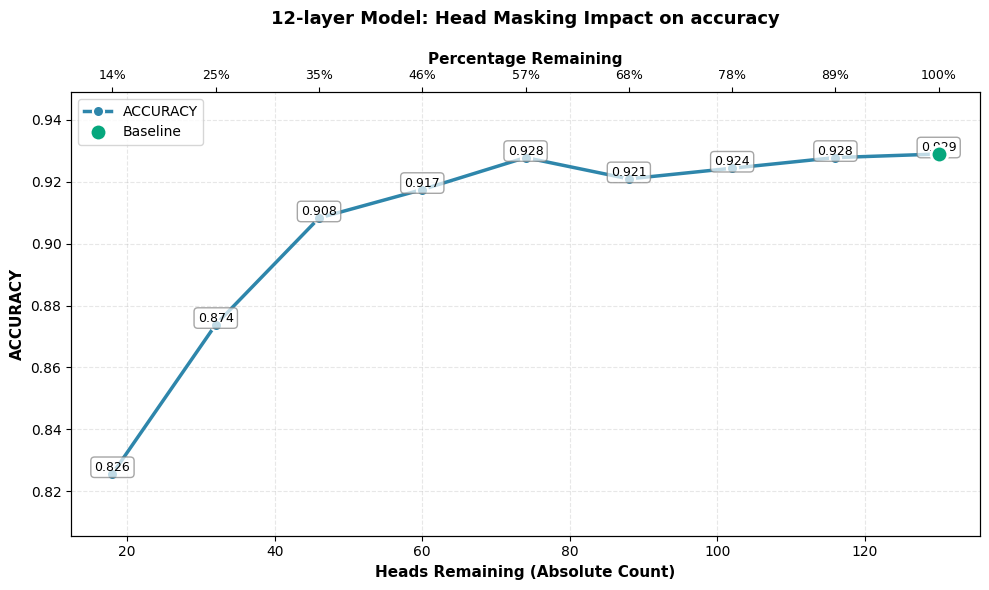

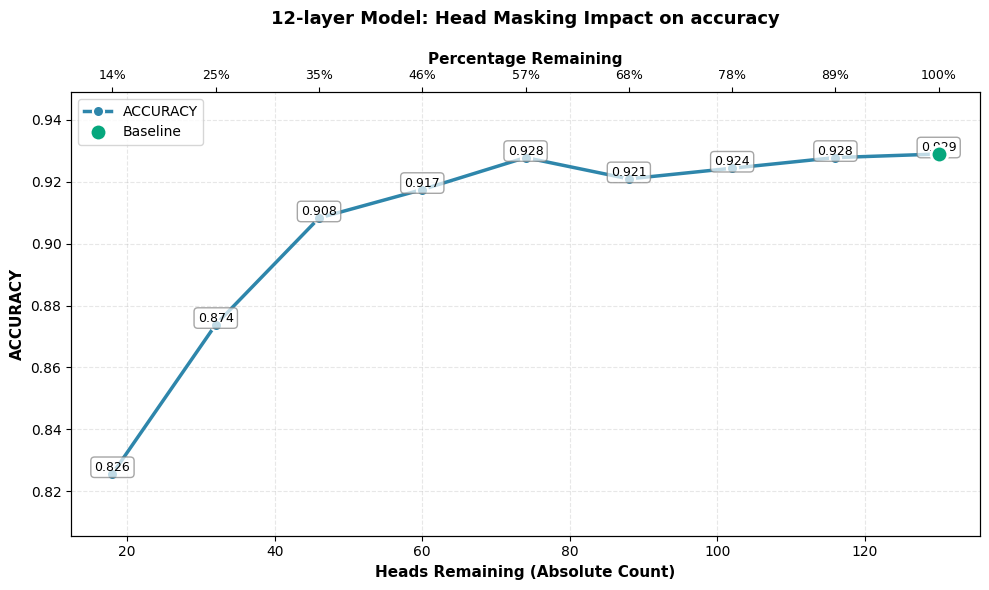

In [57]:
plot_results(
        mask_history_head,
        metric='accuracy',
        component='heads',
        title='12-layer Model: Head Masking Impact on accuracy'
)

In [58]:
remove_importance_masks(model, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [59]:
torch.save(mask_history_head, analysis_save_path + '/head.pt')

### 8 Layers

In [60]:
register_importance_masks(model_8, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (24 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (24 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (12 heads)
  Layer 6: Registered masks (12 heads)
  Layer 7: Registered masks (36 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [61]:
mask_history_head_8 = iterativeMask(
    model_8, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9220

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:07<00:00, 12.70it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 24, Remain: 24 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 12, Remain: 11 (91.67%)
Layer: 6, total: 12, Remain: 11 (91.67%)
Layer: 7, total: 36, Remain: 24 (66.67%)
  Metrics:
    ★ accuracy: 0.9186

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:07<00:00, 12.57it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 24, Remain: 21 (87.5%)
Layer: 4, total: 12, Remain: 11 (91.67%)
Layer: 5, total: 12, Remain: 10 (83.33%)
Layer: 6, total: 12, Remain: 9 (75.0%)
Layer: 7, total: 36, Remain: 17 (47.22%)
  Metrics:
    ★ accuracy: 0.9117

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 6 (50.0%)
Layer: 1, total: 24, Remain: 6 (25.0%)
Layer: 2, total: 12, Remain: 4 (33.33%)
Layer: 3, total: 24, Remain: 4 (16.67%)
Layer: 4, total: 12, Remain: 4 (33.33%)
Layer: 5, total: 12, Remain: 6 (50.0%)
Layer: 6, total: 12, Remain: 5 (41.67%)
Layer: 7, total: 36, Remain: 11 (30.56%)
  Metrics:
    ★ accuracy: 0.8819

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:07<00:00, 12.70it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 3 (25.0%)
Layer: 1, total: 24, Remain: 3 (12.5%)
Layer: 2, total: 12, Remain: 2 (16.67%)
Layer: 3, total: 24, Remain: 3 (12.5%)
Layer: 4, total: 12, Remain: 3 (25.0%)
Layer: 5, total: 12, Remain: 4 (33.33%)
Layer: 6, total: 12, Remain: 5 (41.67%)
Layer: 7, total: 36, Remain: 9 (25.0%)
  Metrics:
    ★ accuracy: 0.8624

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:07<00:00, 13.26it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 0 (0.0%)
Layer: 1, total: 24, Remain: 1 (4.17%)
Layer: 2, total: 12, Remain: 1 (8.33%)
Layer: 3, total: 24, Remain: 3 (12.5%)
Layer: 4, total: 12, Remain: 2 (16.67%)
Layer: 5, total: 12, Remain: 2 (16.67%)
Layer: 6, total: 12, Remain: 3 (25.0%)
Layer: 7, total: 36, Remain: 6 (16.67%)
  Metrics:
    ★ accuracy: 0.8360


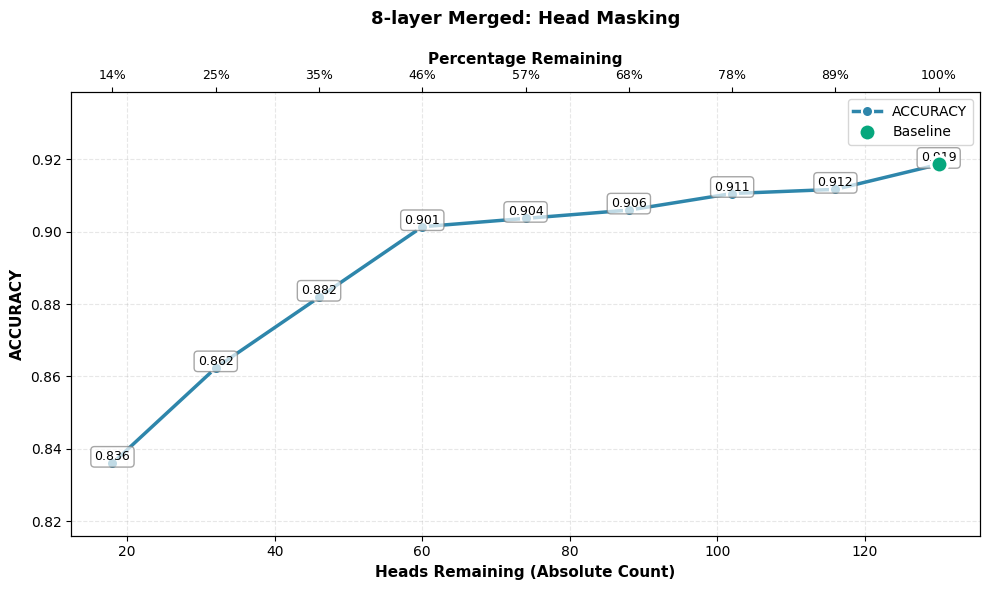

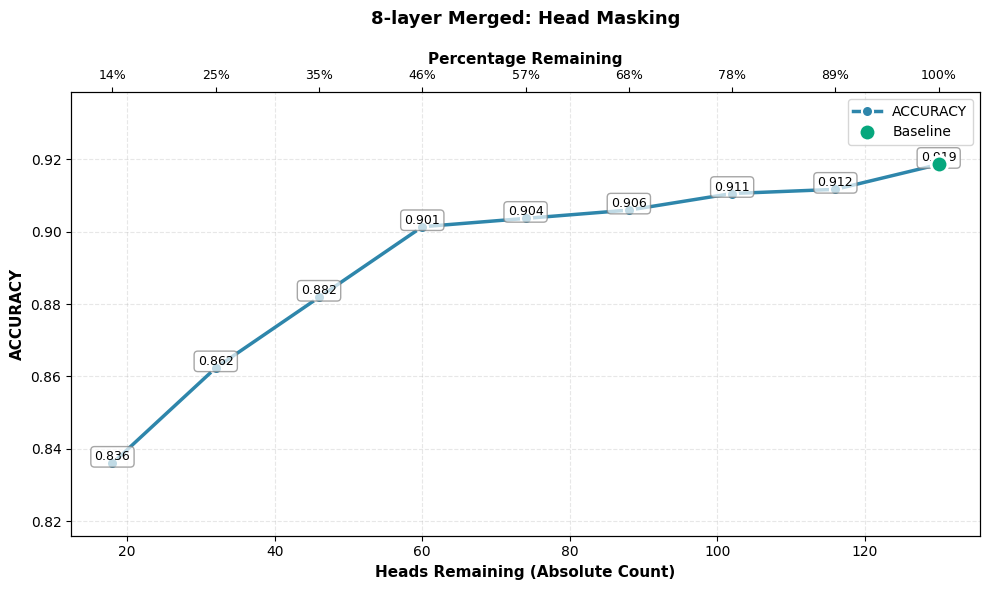

In [62]:
plot_results(
        mask_history_head_8,
        metric='accuracy',
        component='heads',
        title='8-layer Merged: Head Masking'
)

In [63]:
remove_importance_masks(model_8, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [64]:
torch.save(mask_history_head_8, analysis_save_path + '/head_8.pt')

### 7 Layers

In [65]:
register_importance_masks(model_7, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (24 heads)
  Layer 2: Registered masks (12 heads)
  Layer 3: Registered masks (24 heads)
  Layer 4: Registered masks (24 heads)
  Layer 5: Registered masks (12 heads)
  Layer 6: Registered masks (36 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [66]:
mask_history_head_7 = iterativeMask(
    model_7, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9174

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:09<00:00, 10.51it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 24, Remain: 24 (100.0%)
Layer: 4, total: 24, Remain: 24 (100.0%)
Layer: 5, total: 12, Remain: 12 (100.0%)
Layer: 6, total: 36, Remain: 22 (61.11%)
  Metrics:
    ★ accuracy: 0.9197

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:09<00:00, 11.07it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 24, Remain: 24 (100.0%)
Layer: 2, total: 12, Remain: 12 (100.0%)
Layer: 3, total: 24, Remain: 23 (95.83%)
Layer: 4, total: 24, Remain: 21 (87.5%)
Layer: 5, total: 12, Remain: 11 (91.67%)
Layer: 6, total: 36, Remain: 13 (36.11%)
  Metrics:
    ★ accuracy: 0.9186

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 9 (75.0%)
Layer: 1, total: 24, Remain: 5 (20.83%)
Layer: 2, total: 12, Remain: 4 (33.33%)
Layer: 3, total: 24, Remain: 9 (37.5%)
Layer: 4, total: 24, Remain: 8 (33.33%)
Layer: 5, total: 12, Remain: 6 (50.0%)
Layer: 6, total: 36, Remain: 5 (13.89%)
  Metrics:
    ★ accuracy: 0.8991

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:07<00:00, 13.18it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 3 (25.0%)
Layer: 1, total: 24, Remain: 4 (16.67%)
Layer: 2, total: 12, Remain: 2 (16.67%)
Layer: 3, total: 24, Remain: 7 (29.17%)
Layer: 4, total: 24, Remain: 6 (25.0%)
Layer: 5, total: 12, Remain: 5 (41.67%)
Layer: 6, total: 36, Remain: 5 (13.89%)
  Metrics:
    ★ accuracy: 0.8773

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:07<00:00, 12.88it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 0 (0.0%)
Layer: 1, total: 24, Remain: 3 (12.5%)
Layer: 2, total: 12, Remain: 2 (16.67%)
Layer: 3, total: 24, Remain: 2 (8.33%)
Layer: 4, total: 24, Remain: 3 (12.5%)
Layer: 5, total: 12, Remain: 5 (41.67%)
Layer: 6, total: 36, Remain: 3 (8.33%)
  Metrics:
    ★ accuracy: 0.8440


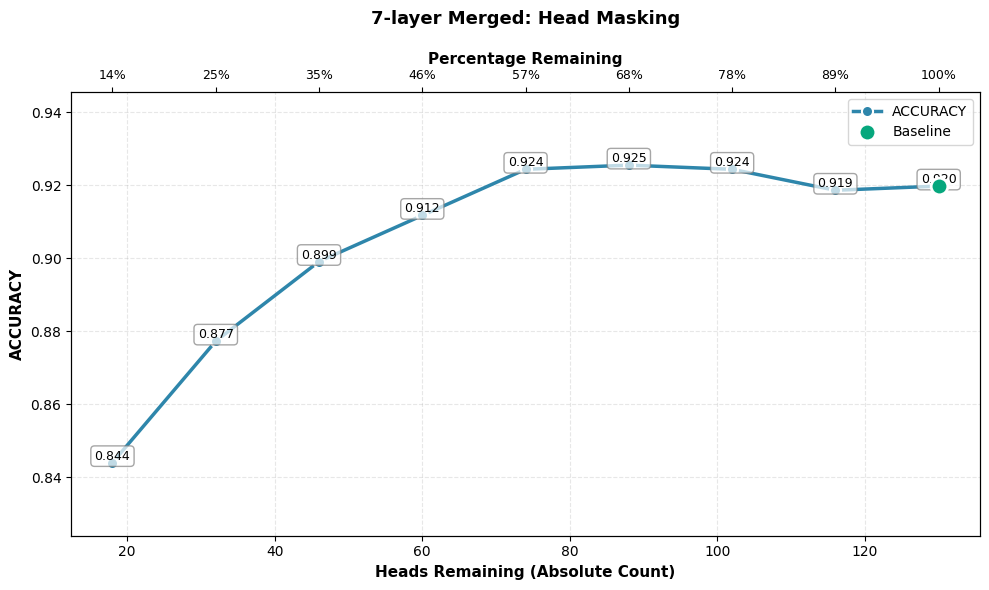

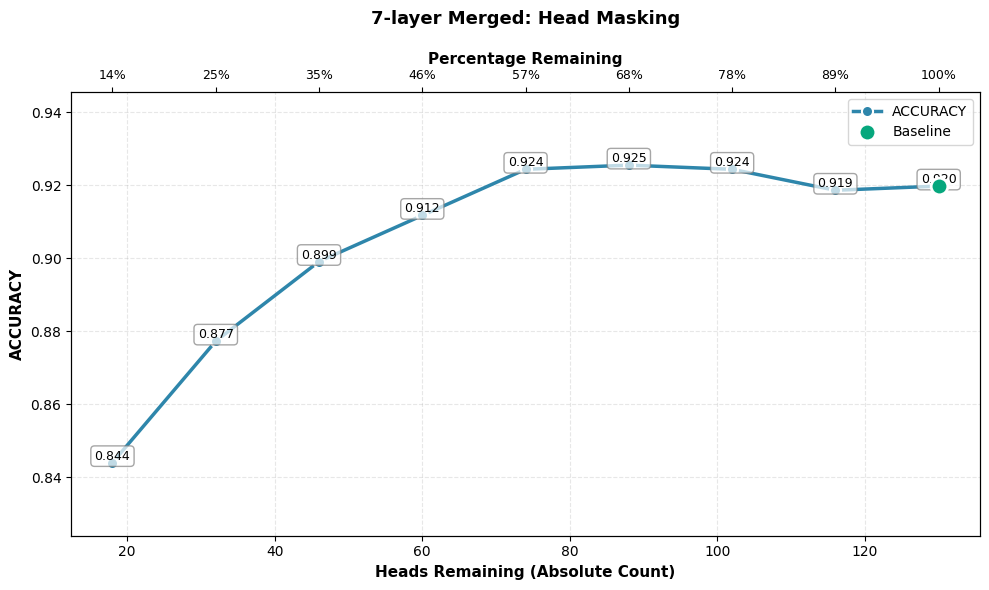

In [67]:
plot_results(
        mask_history_head_7,
        metric='accuracy',
        component='heads',
        title='7-layer Merged: Head Masking'
)

In [68]:
remove_importance_masks(model_7, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [69]:
torch.save(mask_history_head_7, analysis_save_path + '/head_7.pt')

### 6 Layers

In [70]:
register_importance_masks(model_6, device, register_heads=True, register_ffn=False)

  Layer 0: Registered masks (12 heads)
  Layer 1: Registered masks (36 heads)
  Layer 2: Registered masks (24 heads)
  Layer 3: Registered masks (24 heads)
  Layer 4: Registered masks (12 heads)
  Layer 5: Registered masks (36 heads)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [71]:
mask_history_head_6 = iterativeMask(
    model_6, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=True, mask_ffn=False, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of Heads: 144
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9140

--> Round: 0


Computing importance (heads only): 100%|██████████| 100/100 [00:08<00:00, 11.12it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 130, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 36, Remain: 36 (100.0%)
Layer: 2, total: 24, Remain: 24 (100.0%)
Layer: 3, total: 24, Remain: 24 (100.0%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 36, Remain: 22 (61.11%)
  Metrics:
    ★ accuracy: 0.9094

--> Round: 1


Computing importance (heads only): 100%|██████████| 100/100 [00:08<00:00, 11.23it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 116, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 12 (100.0%)
Layer: 1, total: 36, Remain: 33 (91.67%)
Layer: 2, total: 24, Remain: 24 (100.0%)
Layer: 3, total: 24, Remain: 22 (91.67%)
Layer: 4, total: 12, Remain: 12 (100.0%)
Layer: 5, total: 36, Remain: 13 (36.11%)
  Metrics:
    ★ accuracy: 0.9151

--> Round: 2


...


Masking 14 / 144 heads (9.7%)
Remaining Heads: 46, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 7 (58.33%)
Layer: 1, total: 36, Remain: 10 (27.78%)
Layer: 2, total: 24, Remain: 10 (41.67%)
Layer: 3, total: 24, Remain: 7 (29.17%)
Layer: 4, total: 12, Remain: 5 (41.67%)
Layer: 5, total: 36, Remain: 7 (19.44%)
  Metrics:
    ★ accuracy: 0.8979

--> Round: 7


Computing importance (heads only): 100%|██████████| 100/100 [00:07<00:00, 13.40it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 32, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 4 (33.33%)
Layer: 1, total: 36, Remain: 6 (16.67%)
Layer: 2, total: 24, Remain: 6 (25.0%)
Layer: 3, total: 24, Remain: 6 (25.0%)
Layer: 4, total: 12, Remain: 5 (41.67%)
Layer: 5, total: 36, Remain: 5 (13.89%)
  Metrics:
    ★ accuracy: 0.8704

--> Round: 8


Computing importance (heads only): 100%|██████████| 100/100 [00:07<00:00, 13.10it/s]



Masking 14 / 144 heads (9.7%)
Remaining Heads: 18, Total Heads: 144
Head Mask Remaining Stats:
Layer: 0, total: 12, Remain: 2 (16.67%)
Layer: 1, total: 36, Remain: 1 (2.78%)
Layer: 2, total: 24, Remain: 3 (12.5%)
Layer: 3, total: 24, Remain: 4 (16.67%)
Layer: 4, total: 12, Remain: 4 (33.33%)
Layer: 5, total: 36, Remain: 4 (11.11%)
  Metrics:
    ★ accuracy: 0.8429


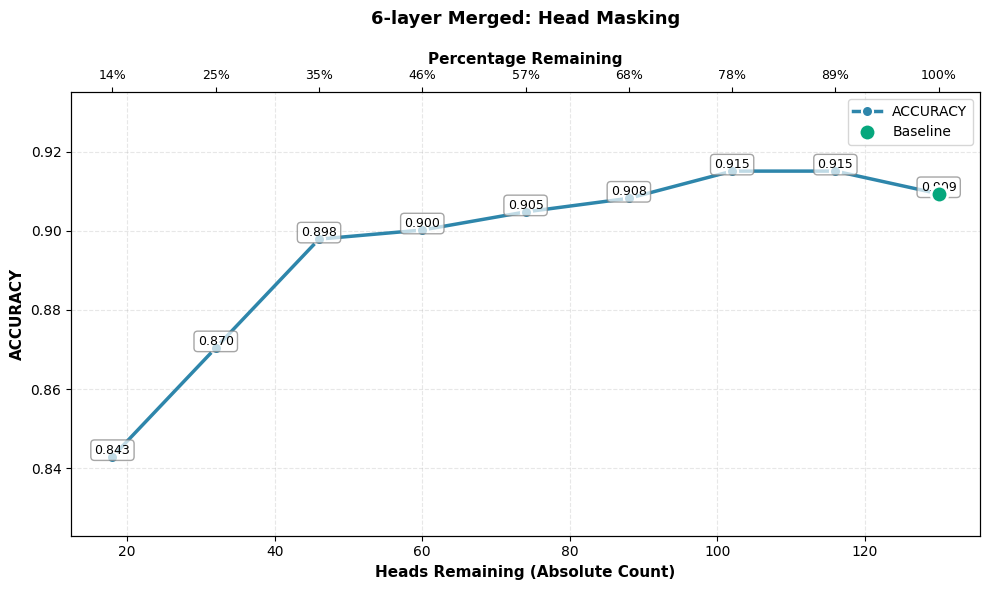

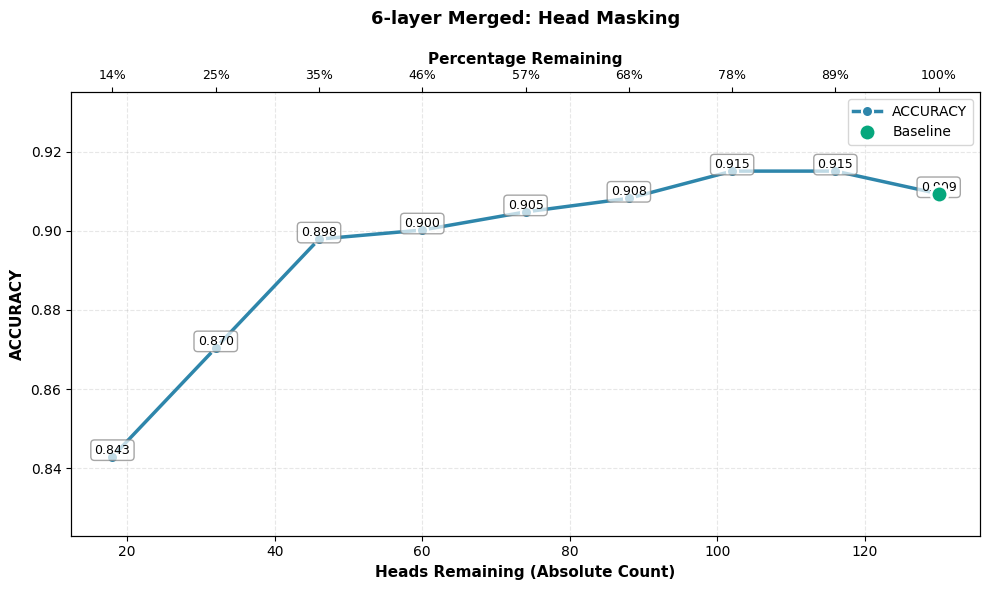

In [72]:
plot_results(
        mask_history_head_6,
        metric='accuracy',
        component='heads',
        title='6-layer Merged: Head Masking'
)

In [73]:
remove_importance_masks(model_6, remove_heads=True, remove_ffn=False)

✓ Removed head masks


In [74]:
torch.save(mask_history_head_6, analysis_save_path + '/head_6.pt')

### Comparision Plot

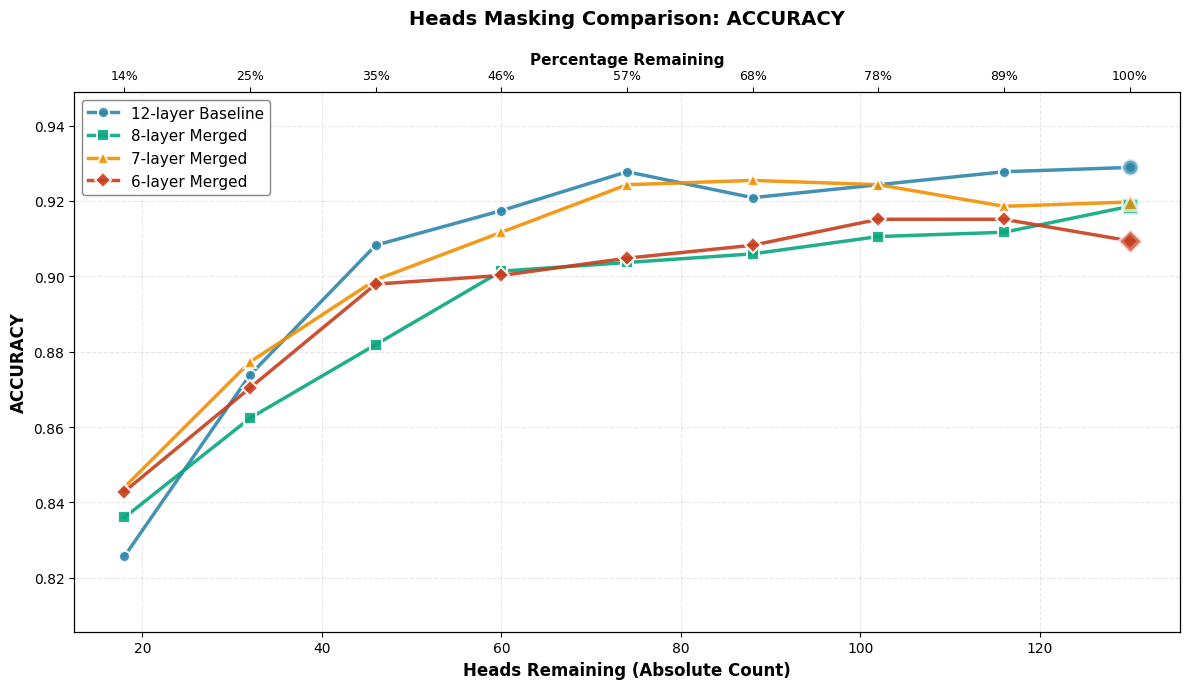

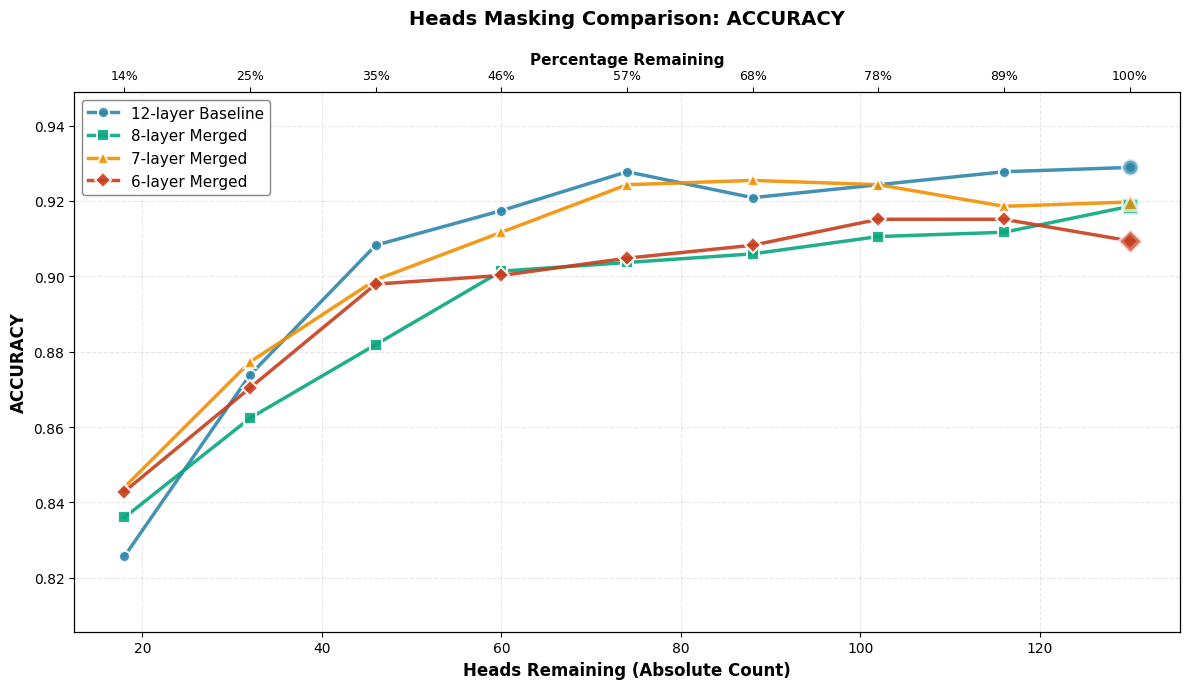

In [75]:
plot_masking_comparison(
    [mask_history_head, mask_history_head_8, mask_history_head_7, mask_history_head_6], 
    labels=['12-layer Baseline', '8-layer Merged', '7-layer Merged', '6-layer Merged'],
    metric='accuracy', component='heads'
)

## 5.2 FFN Neurons

### 12 Layers

In [76]:
register_importance_masks(model, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (3072 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (3072 neurons)
  Layer 6: Registered masks (3072 neurons)
  Layer 7: Registered masks (3072 neurons)
  Layer 8: Registered masks (3072 neurons)
  Layer 9: Registered masks (3072 neurons)
  Layer 10: Registered masks (3072 neurons)
  Layer 11: Registered masks (3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [77]:
mask_history_neuron = iterativeMask(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9312

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:09<00:00, 10.38it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3063 (99.71%)
Layer: 1, total: 3072, Remain: 3060 (99.61%)
Layer: 2, total: 3072, Remain: 3066 (99.8%)
Layer: 3, total: 3072, Remain: 3062 (99.67%)
Layer: 4, total: 3072, Remain: 3066 (99.8%)
Layer: 5, total: 3072, Remain: 3060 (99.61%)
Layer: 6, total: 3072, Remain: 3069 (99.9%)
Layer: 7, total: 3072, Remain: 3068 (99.87%)
Layer: 8, total: 3072, Remain: 3038 (98.89%)
Layer: 9, total: 3072, Remain: 2724 (88.67%)
Layer: 10, total: 3072, Remain: 2176 (70.83%)
Layer: 11, total: 3072, Remain: 726 (23.63%)
  Metrics:
    ★ accuracy: 0.9312

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:09<00:00, 10.47it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3016 (98.18%)
Layer: 1, total: 3072, Remain: 3035 (98.8%)
Layer: 2, total: 3072, Remain: 3058 (99.54%)
Layer: 3, total: 3072, Remain: 3052 (99.35%)
Layer: 4, total: 3072, Remain: 3050 (99.28%)
Layer: 5, total: 3072, Remain: 3039 (98.93%)
Layer: 6, total: 3072, Remain: 3052 (99.35%)
Layer: 7, total: 3072, Remain: 3034 (98.76%)
Layer: 8, total: 3072, Remain: 2642 (86.0%)
Layer: 9, total: 3072, Remain: 1488 (48.44%)
Layer: 10, total: 3072, Remain: 782 (25.46%)
Layer: 11, total: 3072, Remain: 244 (7.94%)
  Metrics:
    ★ accuracy: 0.9289

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 779 (25.36%)
Layer: 1, total: 3072, Remain: 998 (32.49%)
Layer: 2, total: 3072, Remain: 1308 (42.58%)
Layer: 3, total: 3072, Remain: 1596 (51.95%)
Layer: 4, total: 3072, Remain: 1683 (54.79%)
Layer: 5, total: 3072, Remain: 1509 (49.12%)
Layer: 6, total: 3072, Remain: 1469 (47.82%)
Layer: 7, total: 3072, Remain: 1052 (34.24%)
Layer: 8, total: 3072, Remain: 460 (14.97%)
Layer: 9, total: 3072, Remain: 134 (4.36%)
Layer: 10, total: 3072, Remain: 56 (1.82%)
Layer: 11, total: 3072, Remain: 18 (0.59%)
  Metrics:
    ★ accuracy: 0.8888

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:09<00:00, 10.29it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 574 (18.68%)
Layer: 1, total: 3072, Remain: 714 (23.24%)
Layer: 2, total: 3072, Remain: 866 (28.19%)
Layer: 3, total: 3072, Remain: 999 (32.52%)
Layer: 4, total: 3072, Remain: 1070 (34.83%)
Layer: 5, total: 3072, Remain: 983 (32.0%)
Layer: 6, total: 3072, Remain: 990 (32.23%)
Layer: 7, total: 3072, Remain: 709 (23.08%)
Layer: 8, total: 3072, Remain: 329 (10.71%)
Layer: 9, total: 3072, Remain: 83 (2.7%)
Layer: 10, total: 3072, Remain: 46 (1.5%)
Layer: 11, total: 3072, Remain: 13 (0.42%)
  Metrics:
    ★ accuracy: 0.8589

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:07<00:00, 12.62it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 307 (9.99%)
Layer: 1, total: 3072, Remain: 337 (10.97%)
Layer: 2, total: 3072, Remain: 349 (11.36%)
Layer: 3, total: 3072, Remain: 379 (12.34%)
Layer: 4, total: 3072, Remain: 486 (15.82%)
Layer: 5, total: 3072, Remain: 477 (15.53%)
Layer: 6, total: 3072, Remain: 536 (17.45%)
Layer: 7, total: 3072, Remain: 483 (15.72%)
Layer: 8, total: 3072, Remain: 218 (7.1%)
Layer: 9, total: 3072, Remain: 67 (2.18%)
Layer: 10, total: 3072, Remain: 39 (1.27%)
Layer: 11, total: 3072, Remain: 12 (0.39%)
  Metrics:
    ★ accuracy: 0.8131


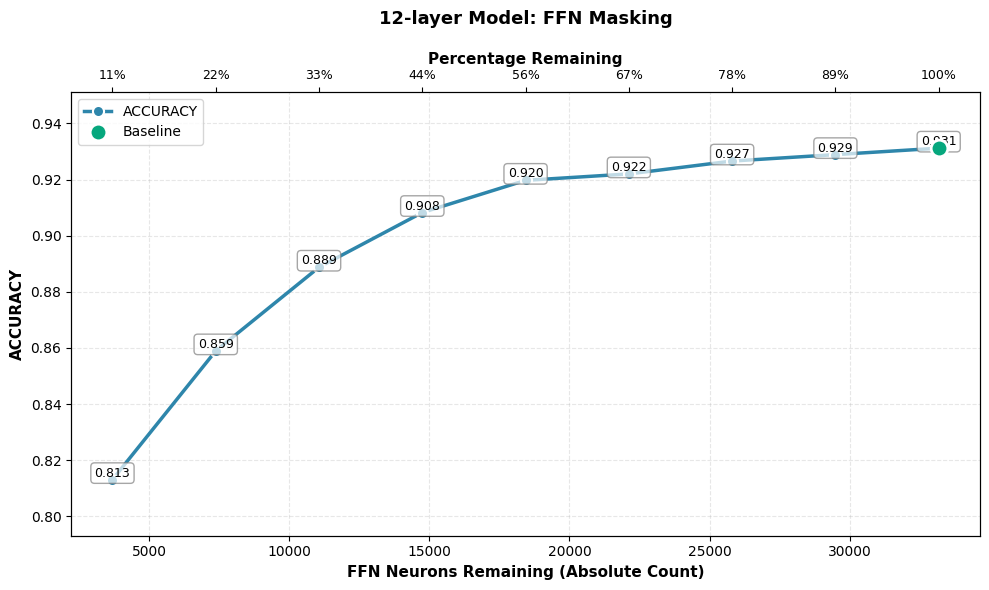

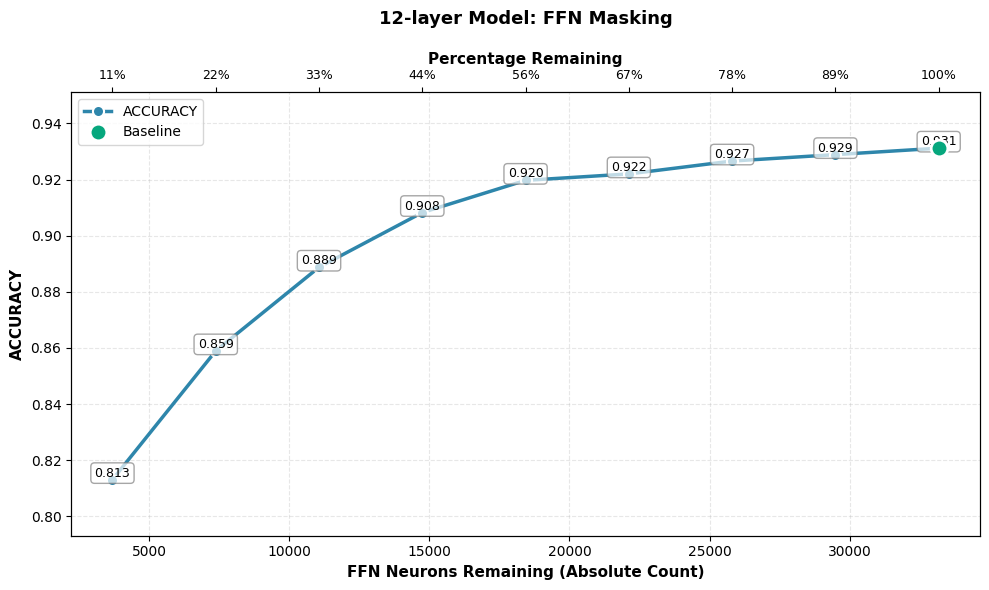

In [78]:
plot_results(mask_history_neuron, metric='accuracy', component='ffn', title='12-layer Model: FFN Masking')

In [79]:
remove_importance_masks(model, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [80]:
torch.save(mask_history_neuron, analysis_save_path + '/neuron.pt')

### 8 Layers

In [81]:
register_importance_masks(model_8, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (6144 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (6144 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (3072 neurons)
  Layer 6: Registered masks (3072 neurons)
  Layer 7: Registered masks (9216 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [82]:
mask_history_neuron_8 = iterativeMask(
    model_8, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9220

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:10<00:00,  9.31it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3069 (99.9%)
Layer: 1, total: 6144, Remain: 6142 (99.97%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 6144, Remain: 6140 (99.93%)
Layer: 4, total: 3072, Remain: 3071 (99.97%)
Layer: 5, total: 3072, Remain: 3072 (100.0%)
Layer: 6, total: 3072, Remain: 3067 (99.84%)
Layer: 7, total: 9216, Remain: 5546 (60.18%)
  Metrics:
    ★ accuracy: 0.9220

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:08<00:00, 11.88it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3059 (99.58%)
Layer: 1, total: 6144, Remain: 6129 (99.76%)
Layer: 2, total: 3072, Remain: 3063 (99.71%)
Layer: 3, total: 6144, Remain: 6113 (99.5%)
Layer: 4, total: 3072, Remain: 3071 (99.97%)
Layer: 5, total: 3072, Remain: 3051 (99.32%)
Layer: 6, total: 3072, Remain: 2820 (91.8%)
Layer: 7, total: 9216, Remain: 2186 (23.72%)
  Metrics:
    ★ accuracy: 0.9232

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1075 (34.99%)
Layer: 1, total: 6144, Remain: 2870 (46.71%)
Layer: 2, total: 3072, Remain: 1995 (64.94%)
Layer: 3, total: 6144, Remain: 2663 (43.34%)
Layer: 4, total: 3072, Remain: 1245 (40.53%)
Layer: 5, total: 3072, Remain: 797 (25.94%)
Layer: 6, total: 3072, Remain: 274 (8.92%)
Layer: 7, total: 9216, Remain: 143 (1.55%)
  Metrics:
    ★ accuracy: 0.8773

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:09<00:00, 10.61it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 739 (24.06%)
Layer: 1, total: 6144, Remain: 1963 (31.95%)
Layer: 2, total: 3072, Remain: 1190 (38.74%)
Layer: 3, total: 6144, Remain: 1760 (28.65%)
Layer: 4, total: 3072, Remain: 841 (27.38%)
Layer: 5, total: 3072, Remain: 574 (18.68%)
Layer: 6, total: 3072, Remain: 196 (6.38%)
Layer: 7, total: 9216, Remain: 113 (1.23%)
  Metrics:
    ★ accuracy: 0.8589

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:09<00:00, 10.15it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 427 (13.9%)
Layer: 1, total: 6144, Remain: 1134 (18.46%)
Layer: 2, total: 3072, Remain: 486 (15.82%)
Layer: 3, total: 6144, Remain: 822 (13.38%)
Layer: 4, total: 3072, Remain: 370 (12.04%)
Layer: 5, total: 3072, Remain: 278 (9.05%)
Layer: 6, total: 3072, Remain: 96 (3.12%)
Layer: 7, total: 9216, Remain: 77 (0.84%)
  Metrics:
    ★ accuracy: 0.8280


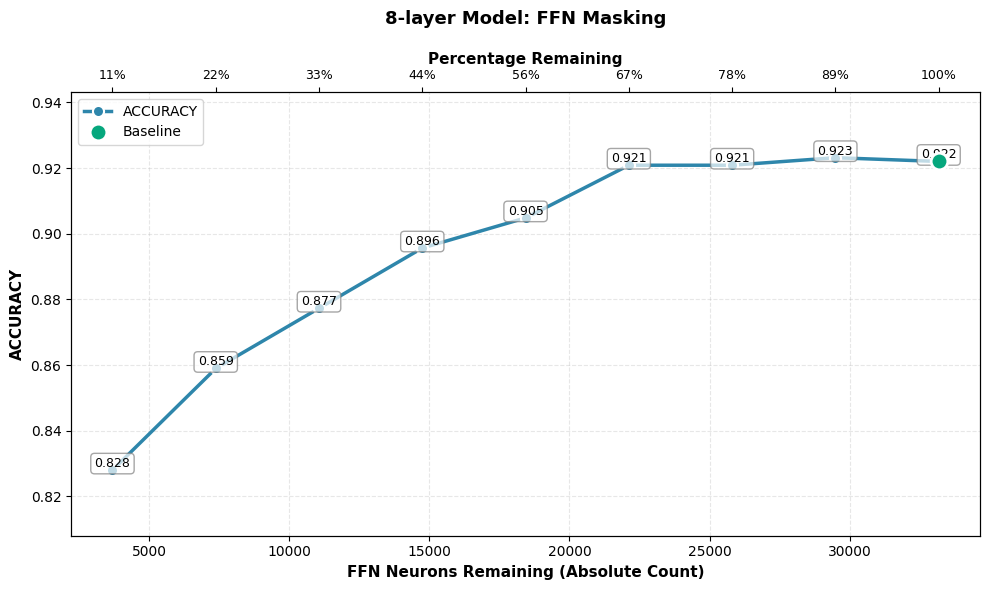

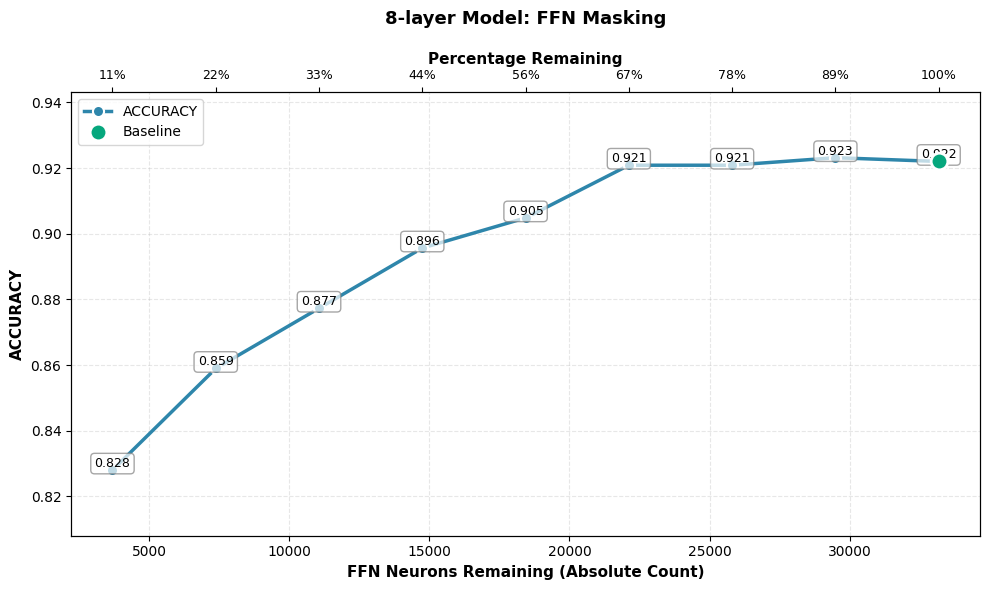

In [83]:
plot_results(mask_history_neuron_8, metric='accuracy', component='ffn', title='8-layer Model: FFN Masking')

In [84]:
remove_importance_masks(model_8, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [85]:
torch.save(mask_history_neuron_8, analysis_save_path + '/neuron_8.pt')

### 7 Layers

In [86]:
register_importance_masks(model_7, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (6144 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (6144 neurons)
  Layer 4: Registered masks (6144 neurons)
  Layer 5: Registered masks (3072 neurons)
  Layer 6: Registered masks (9216 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [87]:
mask_history_neuron_7 = iterativeMask(
    model_7, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9174

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:07<00:00, 13.11it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3070 (99.93%)
Layer: 1, total: 6144, Remain: 6142 (99.97%)
Layer: 2, total: 3072, Remain: 3070 (99.93%)
Layer: 3, total: 6144, Remain: 6141 (99.95%)
Layer: 4, total: 6144, Remain: 6143 (99.98%)
Layer: 5, total: 3072, Remain: 3072 (100.0%)
Layer: 6, total: 9216, Remain: 5540 (60.11%)
  Metrics:
    ★ accuracy: 0.9186

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:08<00:00, 12.46it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3065 (99.77%)
Layer: 1, total: 6144, Remain: 6132 (99.8%)
Layer: 2, total: 3072, Remain: 3066 (99.8%)
Layer: 3, total: 6144, Remain: 6131 (99.79%)
Layer: 4, total: 6144, Remain: 6140 (99.93%)
Layer: 5, total: 3072, Remain: 3031 (98.67%)
Layer: 6, total: 9216, Remain: 1927 (20.91%)
  Metrics:
    ★ accuracy: 0.9186

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1049 (34.15%)
Layer: 1, total: 6144, Remain: 2721 (44.29%)
Layer: 2, total: 3072, Remain: 2065 (67.22%)
Layer: 3, total: 6144, Remain: 3026 (49.25%)
Layer: 4, total: 6144, Remain: 1752 (28.52%)
Layer: 5, total: 3072, Remain: 377 (12.27%)
Layer: 6, total: 9216, Remain: 72 (0.78%)
  Metrics:
    ★ accuracy: 0.8899

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:07<00:00, 12.70it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 728 (23.7%)
Layer: 1, total: 6144, Remain: 1899 (30.91%)
Layer: 2, total: 3072, Remain: 1375 (44.76%)
Layer: 3, total: 6144, Remain: 2009 (32.7%)
Layer: 4, total: 6144, Remain: 1090 (17.74%)
Layer: 5, total: 3072, Remain: 217 (7.06%)
Layer: 6, total: 9216, Remain: 58 (0.63%)
  Metrics:
    ★ accuracy: 0.8704

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:09<00:00, 10.79it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 400 (13.02%)
Layer: 1, total: 6144, Remain: 949 (15.45%)
Layer: 2, total: 3072, Remain: 511 (16.63%)
Layer: 3, total: 6144, Remain: 966 (15.72%)
Layer: 4, total: 6144, Remain: 674 (10.97%)
Layer: 5, total: 3072, Remain: 142 (4.62%)
Layer: 6, total: 9216, Remain: 48 (0.52%)
  Metrics:
    ★ accuracy: 0.8326


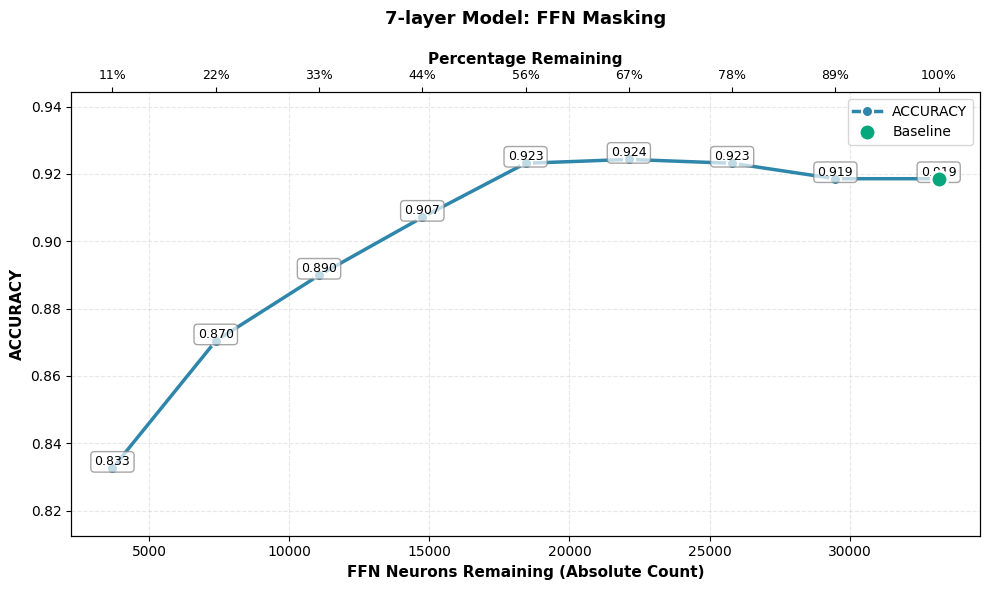

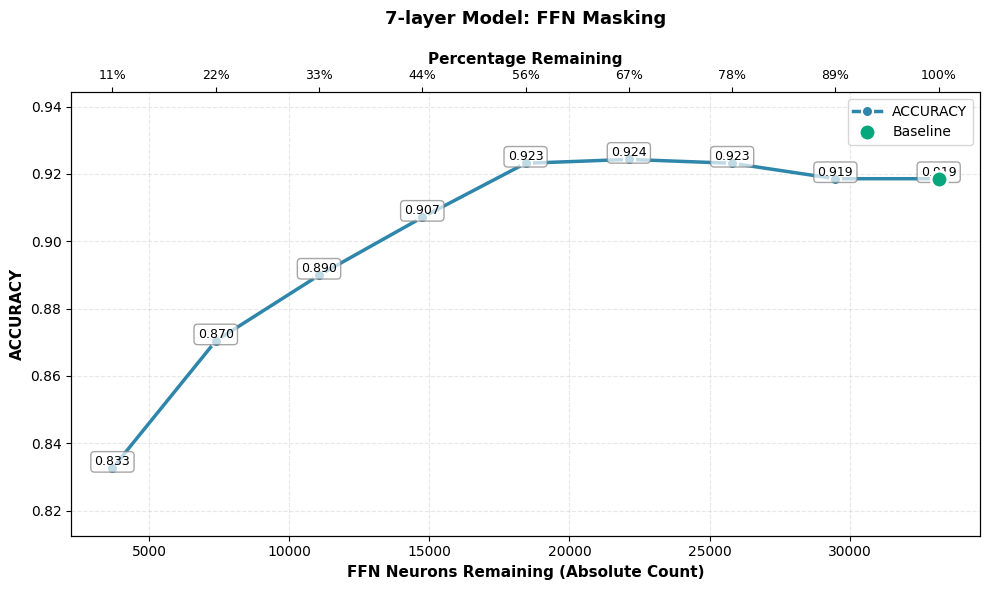

In [88]:
plot_results(mask_history_neuron_7, metric='accuracy', component='ffn', title='7-layer Model: FFN Masking')

In [89]:
remove_importance_masks(model_7, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [90]:
torch.save(mask_history_neuron_7, analysis_save_path + '/neuron_7.pt')

### 6 Layers

In [91]:
register_importance_masks(model_6, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (9216 neurons)
  Layer 2: Registered masks (6144 neurons)
  Layer 3: Registered masks (6144 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (9216 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [92]:
mask_history_neuron_6 = iterativeMask(
    model_6, train_dataloader, val_dataloader, device, task_name, max_batches=100, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=9
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
    ★ accuracy: 0.9140

--> Round: 0


Computing importance (FFN only): 100%|██████████| 100/100 [00:07<00:00, 13.07it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3069 (99.9%)
Layer: 1, total: 9216, Remain: 9205 (99.88%)
Layer: 2, total: 6144, Remain: 6140 (99.93%)
Layer: 3, total: 6144, Remain: 6143 (99.98%)
Layer: 4, total: 3072, Remain: 3072 (100.0%)
Layer: 5, total: 9216, Remain: 5549 (60.21%)
  Metrics:
    ★ accuracy: 0.9140

--> Round: 1


Computing importance (FFN only): 100%|██████████| 100/100 [00:07<00:00, 12.88it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3067 (99.84%)
Layer: 1, total: 9216, Remain: 9195 (99.77%)
Layer: 2, total: 6144, Remain: 6134 (99.84%)
Layer: 3, total: 6144, Remain: 6141 (99.95%)
Layer: 4, total: 3072, Remain: 3051 (99.32%)
Layer: 5, total: 9216, Remain: 1904 (20.66%)
  Metrics:
    ★ accuracy: 0.9151

--> Round: 2


...


Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 11062, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 1206 (39.26%)
Layer: 1, total: 9216, Remain: 4188 (45.44%)
Layer: 2, total: 6144, Remain: 3164 (51.5%)
Layer: 3, total: 6144, Remain: 1992 (32.42%)
Layer: 4, total: 3072, Remain: 448 (14.58%)
Layer: 5, total: 9216, Remain: 64 (0.69%)
  Metrics:
    ★ accuracy: 0.8865

--> Round: 7


Computing importance (FFN only): 100%|██████████| 100/100 [00:07<00:00, 12.52it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 7376, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 860 (27.99%)
Layer: 1, total: 9216, Remain: 2915 (31.63%)
Layer: 2, total: 6144, Remain: 2079 (33.84%)
Layer: 3, total: 6144, Remain: 1214 (19.76%)
Layer: 4, total: 3072, Remain: 260 (8.46%)
Layer: 5, total: 9216, Remain: 48 (0.52%)
  Metrics:
    ★ accuracy: 0.8544

--> Round: 8


Computing importance (FFN only): 100%|██████████| 100/100 [00:09<00:00, 10.52it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 3690, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 508 (16.54%)
Layer: 1, total: 9216, Remain: 1579 (17.13%)
Layer: 2, total: 6144, Remain: 889 (14.47%)
Layer: 3, total: 6144, Remain: 551 (8.97%)
Layer: 4, total: 3072, Remain: 121 (3.94%)
Layer: 5, total: 9216, Remain: 42 (0.46%)
  Metrics:
    ★ accuracy: 0.8349


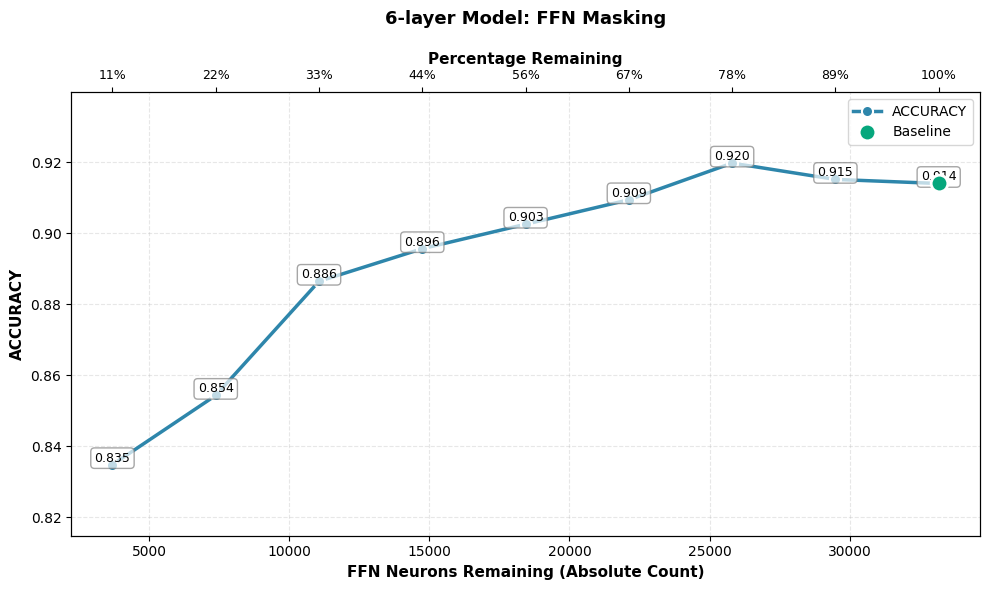

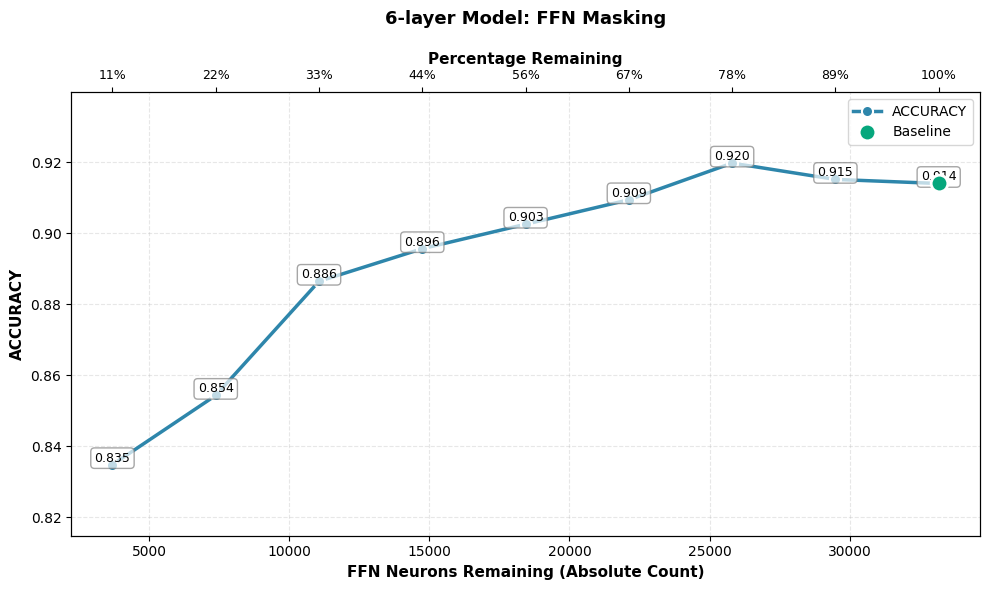

In [93]:
plot_results(mask_history_neuron_6, metric='accuracy', component='ffn', title='6-layer Model: FFN Masking')

In [94]:
remove_importance_masks(model_6, remove_heads=False, remove_ffn=True)

✓ Removed FFN masks


In [95]:
torch.save(mask_history_neuron_6, analysis_save_path + '/neuron_6.pt')

### Plot Comparision

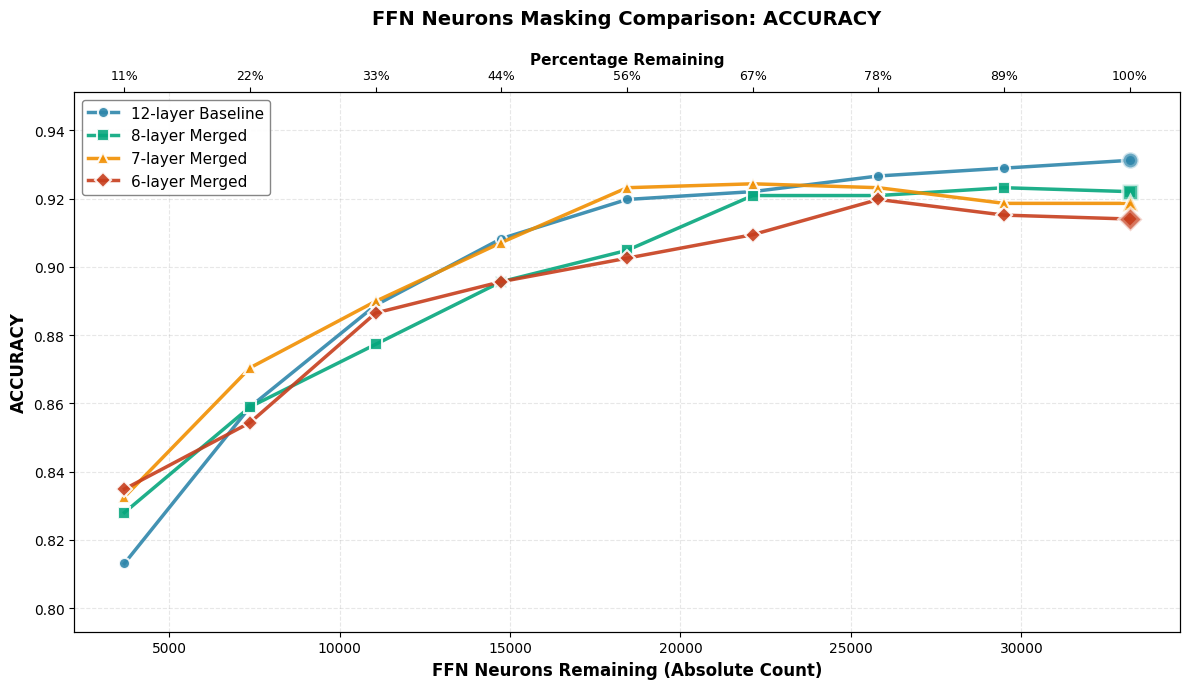

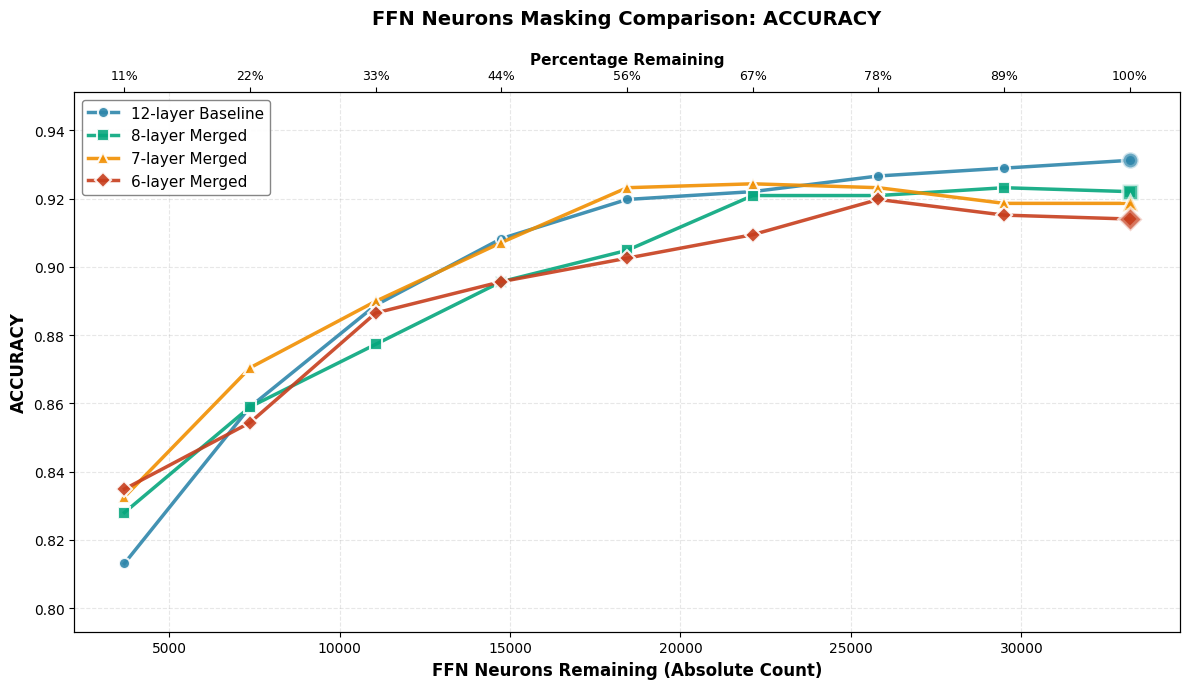

In [96]:
plot_masking_comparison(
    [mask_history_neuron, mask_history_neuron_8, mask_history_neuron_7, mask_history_neuron_6], 
    labels=['12-layer Baseline', '8-layer Merged', '7-layer Merged', '6-layer Merged'], 
    metric='accuracy', component='ffn'
)